In [1]:
import os
import sys
import torch
import json
import plotly.express as px
print("importing transformerlens utils")
from transformer_lens import utils
print("finished importing transformerlens utils")
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
cwd = cwd.split("notebooks")[0]
print(cwd)
sys.path.append(cwd + "/scripts")
from error_eval import *
from plots import *

importing transformerlens utils
finished importing transformerlens utils
/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/


# Get model names

In [2]:
from e2e_sae.scripts.analysis.utils import create_run_df, get_df_gpt2
df = get_df_gpt2()

Processing runs: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 299/299 [00:12<00:00, 24.87it/s]


In [3]:
performance_df = df.copy()

#get models that were used in the performance plot of the paper
performance_df = df.loc[(df["ratio"] == 60) & (df["seed"] == 0) & (df["n_samples"] == 400_000)]

# Ignore specialised runs
performance_df = performance_df.loc[
    ~performance_df["name"].str.contains("seed-comparison")
    & ~performance_df["name"].str.contains("lr-comparison")
    & ~performance_df["name"].str.contains("lower-downstream")
    & -performance_df["name"].str.contains("e2e-local")
    & ~performance_df["name"].str.contains("recon-all")
    & ~performance_df["name"].str.contains("misc_")]


In [4]:
columns_list = ["id", "sae_pos", "run_type", "layer", "L0", "CELossIncrease", "alive_dict_elements"]
df_local = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "local")].sort_values("L0")
df_e2e = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "e2e")].sort_values("L0")
df_downstream = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "downstream")].sort_values("L0")

In [5]:
def plot_modelwise_kl_average(result_dfs, models, kl_cols, kl_col_labels, model_name_list):
    mean_df = pd.DataFrame({
        l: result_dfs[l].mean(axis=0) for l in range(len(models))
    }).T

    fig, ax = plt.subplots(figsize=(10, 5))

    mean_df["Model Name"] = model_name_list
    mean_df[kl_cols + ["Model Name"]].rename(columns=kl_col_labels).plot(x = "Model Name", kind='bar', ax=ax)

    ax.set_ylabel('KL(original prediction || prediction w/ substitution)', fontsize=11)
    ax.set_xlabel('SAE Model', fontsize=12)
    ax.legend(title='Substitution type', fontsize=12, title_fontsize=14)

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    format_subplot(ax)
    
    return mean_df, fig, ax

# New Baseline

In [6]:
df_interest = df_local[df_local["L0"] > 30]

pos = 'all'
# layers = list(range(12))
layers = [6]
sae_name = 'gpt2_resid_pre'

model_list = [""]
model_list.extend([f"e2e_{x}_" for x in df_interest["id"]])
result_dfs = {}
for i in range(len(model_list)):
    data_path = os.path.join(
        cwd + 'results/error_eval',
        sae_name,
        f'{model_list[i]}layer_6_pos_{pos}.csv',
    )
    result_dfs[i] = pd.read_csv(data_path)

In [7]:
model_names_list = ["Joseph Bloom \nSAE \nL0 = 50"] + [f"Braun et al. \n$SAE_{{local}}$ \nL0 = {x:.1f}" for x in df_interest["L0"]]
# model_names_list.append(["Joseph Bloom \nSAE \nL0 = 50"])

In [8]:
col_labels = {
    'substitution_kl': 'SAE(x)',
    'norm_corrected_substitution_kl': 'norm corrected SAE(x)',
    'cos_corrected_substitution_kl': '$(\|x_{SAE}\| / \|x\|) * x$',
    'l2_error_preserving_substitution_kl': '$\epsilon$ isotropic random',
    'l2_error_preserving_substitution_cov_random_subtraction_kl': '$\epsilon$ cov-random mixture-difference',
    'l2_error_preserving_substitution_real_activation_subtraction_kl': '$\epsilon$ real mixture-difference',
    'cos_preserving_substitution_w_sae_norm_kl': '$\\theta$-random w/ SAE norm',
    'cos_preserving_substitution_w_true_norm_kl': '$\\theta$-random w/ true norm',
    'model_name': 'Model Name',
    'norm_ratio': 'L2 Ratio',
}

kl_main_cols = ['substitution_kl', 'l2_error_preserving_substitution_kl', 'l2_error_preserving_substitution_cov_random_subtraction_kl',
                'l2_error_preserving_substitution_real_activation_subtraction_kl']
kl_all_cols = ['substitution_kl', 'norm_corrected_substitution_kl', 'l2_error_preserving_substitution_kl', 
               'cos_corrected_substitution_kl',
               'cos_preserving_substitution_w_sae_norm_kl', 'cos_preserving_substitution_w_true_norm_kl']


<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_5205/370920359.py:4: SyntaxWarning: invalid escape sequence '\|'
  'cos_corrected_substitution_kl': '$(\|x_{SAE}\| / \|x\|) * x$',
/tmp/ipykernel_5205/370920359.py:5: SyntaxWarning: invalid escape sequence '\e'
  'l2_error_preserving_substitution_kl': '$\epsilon$ isotropic random',
/tmp/ipykernel_5205/370920359.py:6: SyntaxWarning: invalid escape sequence '\e'
  'l2_error_preserving_substitution_cov_random_subtraction_kl': '$\epsilon$ cov-random mixture-difference',
/tmp/ipykernel_5205/370920359.py:7: SyntaxWarning: invalid escape sequence '\e'
  'l2_error_preserving_substitutio

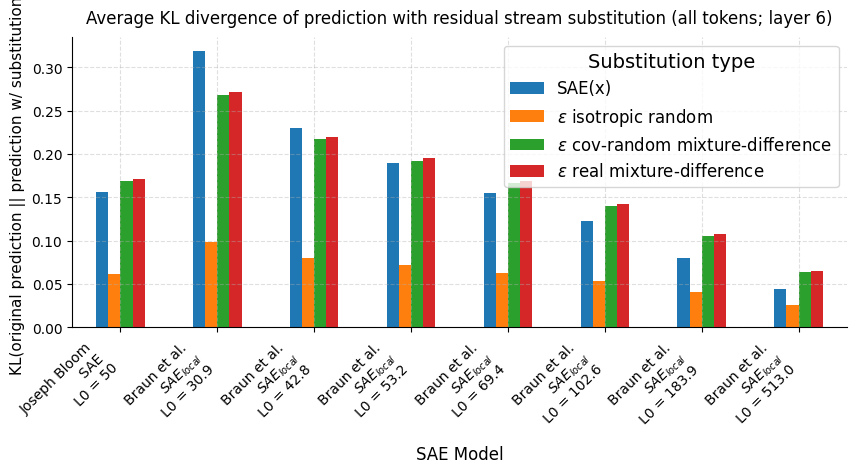

In [9]:
# kl_main_cols = ['substitution_kl', 'l2_error_preserving_substitution_kl', 'cos_corrected_substitution_kl']
mean_df, fig, ax = plot_modelwise_kl_average(result_dfs, model_list, kl_main_cols, col_labels, model_names_list)
ax.set_title('Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)', y=1.02)

plt.subplots_adjust(bottom=0.3)
plt.savefig(f"{cwd}/results/figures/pathological_error_analysis_SAE_local.png", dpi = 500)

<Axes: xlabel='reconstruction_error', ylabel='substitution_kl'>

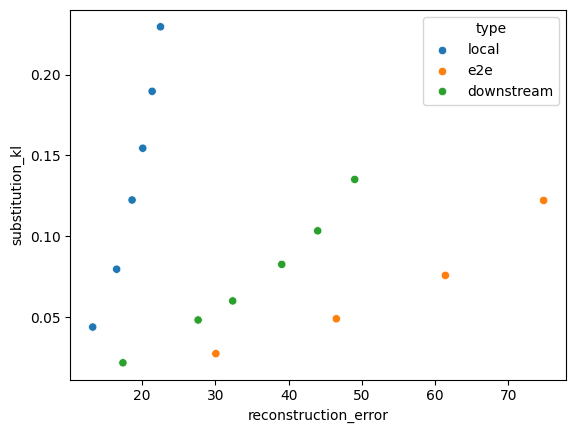

In [161]:
sns.scatterplot(data=mean_df, x="reconstruction_error", y="substitution_kl", hue="type")
